In [36]:
import os
from pathlib import Path
import shutil
from collections import defaultdict
import json

from PIL import Image

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from tqdm.auto import tqdm
import albumentations as A 

In [2]:
meta= pd.read_csv(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\metadata.csv")
meta.sample(5)

,filename,dataset,unified_label,original_label
2252,APTOS_image_2 (68).png,APTOS2019,Diabetic Retinopathy,DR
2550,APTOS_image_5 (35).png,APTOS2019,Diabetic Retinopathy,DR
340,ACRIMA_Im341_g_ACRIMA.jpg,ACRIMA,Glaucoma,Glaucoma
4361,ORIGA_222.jpg,ORIGA,Normal,0
3996,APTOS_image_02897.png,APTOS2019,Normal,No DR


In [3]:
meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 11839 entries, 0 to 11838
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   filename        11839 non-null  str  
 1   dataset         11839 non-null  str  
 2   unified_label   11839 non-null  str  
 3   original_label  11839 non-null  str  
dtypes: str(4)
memory usage: 370.1 KB


In [4]:
meta.dataset.value_counts()

dataset
ODIR5K       7000
APTOS2019    3484
ACRIMA        705
ORIGA         650
Name: count, dtype: int64

In [5]:
meta.unified_label.value_counts()

unified_label
Normal                  4698
Diabetic Retinopathy    4113
Others                  1102
Glaucoma                 930
Cataract                 340
Myopia                   294
AMD                      274
Hypertension              88
Name: count, dtype: int64

In [6]:
missing = meta.isnull().sum()
missing_pct = (missing / len(meta) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
print(missing_df)

                missing  pct
filename              0  0.0
dataset               0  0.0
unified_label         0  0.0
original_label        0  0.0


In [7]:
dup_rows = meta.duplicated().sum()
dup_filenames = meta["filename"].duplicated().sum()
print(f"Duplicate rows: {dup_rows}")
print(f"Duplicate filenames: {dup_filenames}")

Duplicate rows: 0
Duplicate filenames: 0


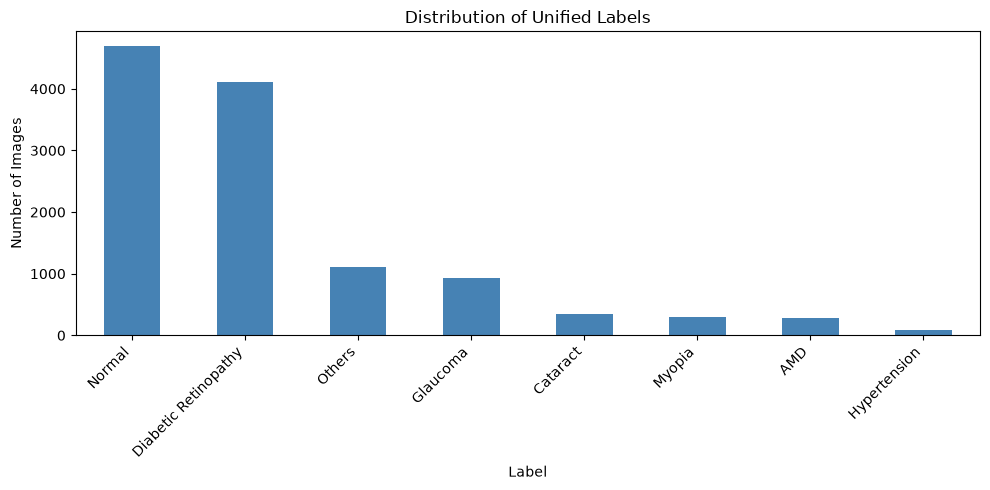

In [8]:
plt.figure(figsize=(10, 5))
meta["unified_label"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Distribution of Unified Labels")
plt.xlabel("Label")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

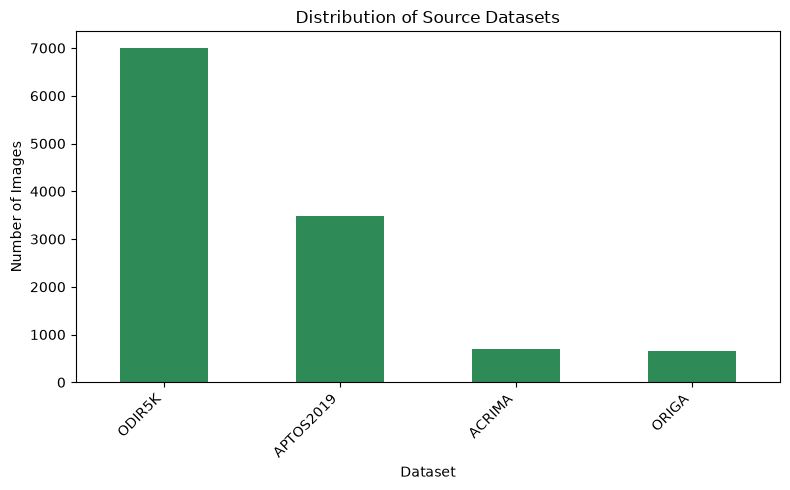

In [9]:
plt.figure(figsize=(8, 5))
meta["dataset"].value_counts().plot(kind="bar", color="seagreen")
plt.title("Distribution of Source Datasets")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
ct = pd.crosstab(meta["dataset"], meta["unified_label"])
print(ct)

unified_label  AMD  Cataract  Diabetic Retinopathy  Glaucoma  Hypertension  \
dataset                                                                      
ACRIMA           0         0                     0       396             0   
APTOS2019        0         0                  1857         0             0   
ODIR5K         274       340                  2256       366            88   
ORIGA            0         0                     0       168             0   

unified_label  Myopia  Normal  Others  
dataset                                
ACRIMA              0     309       0  
APTOS2019           0    1627       0  
ODIR5K            294    2280    1102  
ORIGA               0     482       0  


In [11]:
IMAGES_DIR = Path(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\images")

# Get all files in the folder (including subfolders)
all_files = [p for p in IMAGES_DIR.rglob("*") if p.is_file()]

print(f"Total files in images/: {len(all_files)}")

Total files in images/: 11839


Columns: ['filename', 'dataset', 'unified_label', 'original_label']
Total images to show: 16


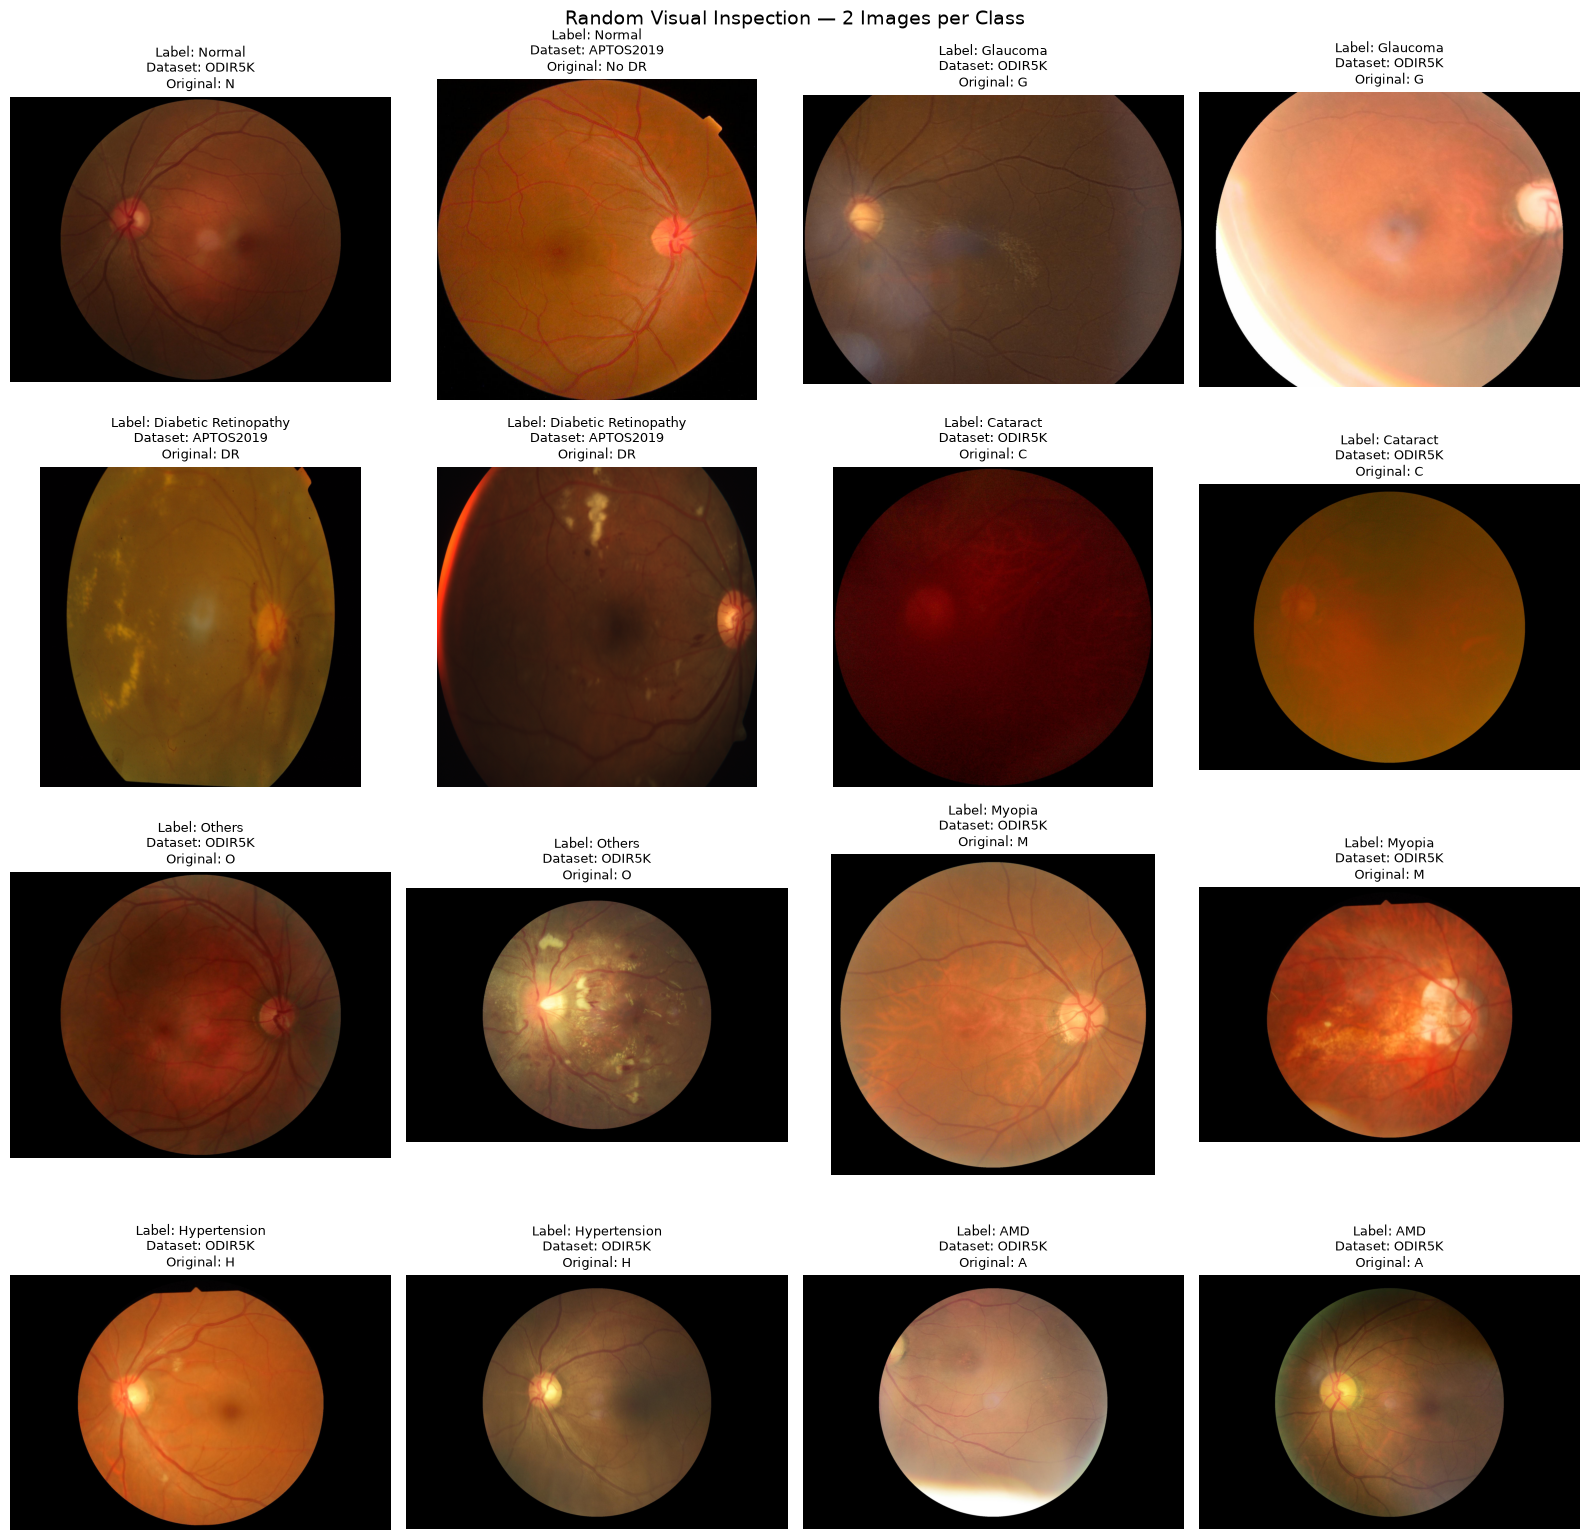

In [12]:
# Take 2 random samples from each class
n_per_class = 2

sample_parts = []

for label in meta["unified_label"].unique():
    class_df = meta[meta["unified_label"] == label]

    sample_parts.append(
        class_df.sample(
            n=min(n_per_class, len(class_df)),
            random_state=42
        )
    )

sample_df = pd.concat(sample_parts, ignore_index=True)

print("Columns:", sample_df.columns.tolist())
print(f"Total images to show: {len(sample_df)}")

# Make sure image_path exists
if "image_path" not in sample_df.columns:
    sample_df["image_path"] = sample_df["filename"].apply(
        lambda x: IMAGES_DIR / x
    )

# Grid
n = len(sample_df)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 4, rows * 4)
)

axes = np.atleast_1d(axes).flatten()

# Display images
for i, (_, row) in enumerate(sample_df.iterrows()):

    ax = axes[i]

    try:
        image_path = row["image_path"]

        # Open image
        img = Image.open(image_path).convert("RGB")

        # Display
        ax.imshow(img)

        # Metadata
        label = row["unified_label"]
        dataset = row["dataset"]
        original = row["original_label"]

        ax.set_title(
            f"Label: {label}\n"
            f"Dataset: {dataset}\n"
            f"Original: {original}",
            fontsize=9
        )

        ax.axis("off")

    except Exception as e:

        print(f"Error loading: {image_path}")
        print(f"Error: {e}")

        ax.axis("off")
        ax.text(
            0.5,
            0.5,
            f"ERROR\n{e}",
            ha="center",
            va="center"
        )

# Hide unused axes
for j in range(len(sample_df), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Random Visual Inspection — 2 Images per Class",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [13]:
metadata_files = set(meta["filename"])

folder_files = {
    p.name
    for p in IMAGES_DIR.rglob("*")
    if p.is_file()
}

missing_from_folder = metadata_files - folder_files
extra_in_folder = folder_files - metadata_files

print(f"Missing from images folder: {len(missing_from_folder)}")
print(f"Extra files in images folder: {len(extra_in_folder)}")

Missing from images folder: 0
Extra files in images folder: 0


In [14]:
class_counts = meta["unified_label"].value_counts()

class_distribution = pd.DataFrame({
    "count": class_counts,
    "percentage": (class_counts / len(meta) * 100).round(2)
})

print(class_distribution)

                      count  percentage
unified_label                          
Normal                 4698       39.68
Diabetic Retinopathy   4113       34.74
Others                 1102        9.31
Glaucoma                930        7.86
Cataract                340        2.87
Myopia                  294        2.48
AMD                     274        2.31
Hypertension             88        0.74


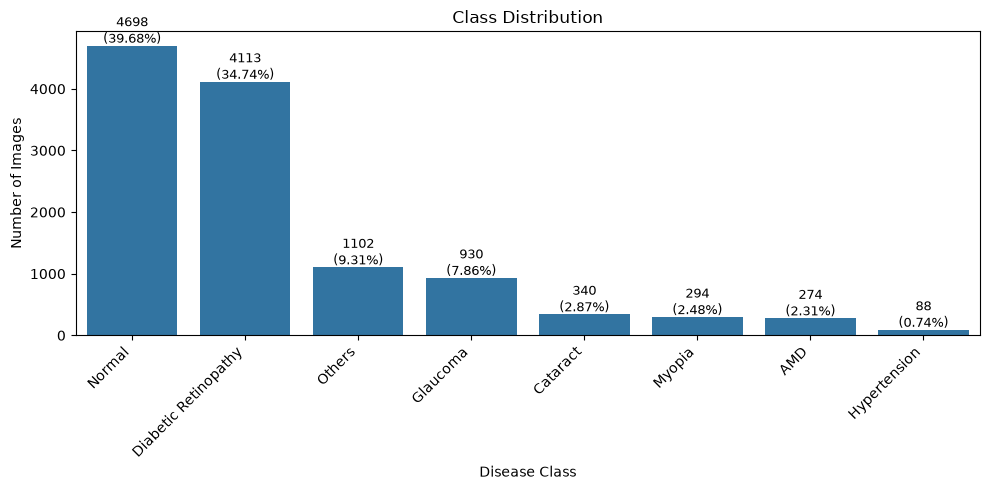

In [15]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=class_distribution.index,
    y=class_distribution["count"]
)

plt.title("Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

for i, count in enumerate(class_distribution["count"]):
    ax.text(
        i,
        count + 50,
        f"{count}\n({class_distribution['percentage'].iloc[i]}%)",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [16]:
train_df, temp_df = train_test_split(
    meta,
    test_size=0.30,
    stratify=meta['unified_label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['unified_label'],
    random_state=42
)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Train: 8287  Val: 1776  Test: 1776


In [19]:
IMAGES_DIR = Path(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\images")
all_files  = {p.name: p for p in IMAGES_DIR.rglob("*") if p.is_file()}

print("Total files found:", len(all_files))

train_dist = train_df['unified_label'].value_counts()
print("\nTrain distribution:")
print(train_dist)

Total files found: 11839

Train distribution:
unified_label
Normal                  3288
Diabetic Retinopathy    2879
Others                   771
Glaucoma                 651
Cataract                 238
Myopia                   206
AMD                      192
Hypertension              62
Name: count, dtype: int64


In [20]:
TARGET = {
    'Normal':                train_dist['Normal'],                 # 3288 - no aug
    'Diabetic Retinopathy':  train_dist['Diabetic Retinopathy'],   # 2879 - no aug
    'Others':                1500,
    'Glaucoma':              1500,
    'Cataract':              1200,
    'Myopia':                1000,
    'AMD':                   1000,
    'Hypertension':           700,
}

for cls, tgt in TARGET.items():
    cur = train_dist.get(cls, 0)
    print(f"{cls:25s}  {cur:5d} → {tgt:5d}   (need {max(0, tgt-cur)} aug)")

Normal                      3288 →  3288   (need 0 aug)
Diabetic Retinopathy        2879 →  2879   (need 0 aug)
Others                       771 →  1500   (need 729 aug)
Glaucoma                     651 →  1500   (need 849 aug)
Cataract                     238 →  1200   (need 962 aug)
Myopia                       206 →  1000   (need 794 aug)
AMD                          192 →  1000   (need 808 aug)
Hypertension                  62 →   700   (need 638 aug)


In [21]:
def get_train_aug():
    """كل التحويلات دي بتحافظ على حجم الصورة الأصلي."""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, border_mode=0, p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.10, rotate_limit=10,
            border_mode=0, p=0.4
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.20, contrast_limit=0.20, p=0.5
        ),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
        A.HueSaturationValue(
            hue_shift_limit=5, sat_shift_limit=15, val_shift_limit=10, p=0.3
        ),
        A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
    ])

In [22]:
AUG_DIR = Path(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\images_augmented")
AUG_DIR.mkdir(parents=True, exist_ok=True)

aug_transform = get_train_aug()
records = []

for cls, target_n in TARGET.items():
    cls_df = train_df[train_df['unified_label'] == cls].reset_index(drop=True)
    current = len(cls_df)
    needed  = target_n - current

    if needed <= 0:
        print(f"[{cls}] already {current} ≥ {target_n}, skip.")
        continue

    out_dir = AUG_DIR / cls
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n[{cls}] {current} → {target_n}  (+{needed})")
    src_rows = cls_df.to_dict('records')
    idx = 0

    for i in tqdm(range(needed), desc=cls):
        row = src_rows[idx % len(src_rows)]
        idx += 1

        src_path = all_files.get(row['filename'])
        if src_path is None:
            continue

        try:
            img = np.array(Image.open(src_path).convert('RGB'))
        except Exception as e:
            print(f"skip {src_path}: {e}")
            continue

        # كل مرة ناخد transform جديد (random) فالصورة هتختلف
        aug_img = aug_transform(image=img)['image']

        new_name = f"AUG_{i:05d}_{row['filename']}"
        Image.fromarray(aug_img).save(out_dir / new_name)

        records.append({
            'filename':        new_name,
            'dataset':         row['dataset'],
            'unified_label':   cls,
            'original_label':  row['original_label'],
            'is_augmented':    True,
            'source_filename': row['filename'],
        })

aug_df = pd.DataFrame(records)
print(f"\nTotal augmented images created: {len(aug_df)}")

d:\Education\Cellula\EyeDisease\EyeDisease\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_17416\291566997.py:17: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),


[Normal] already 3288 ≥ 3288, skip.
[Diabetic Retinopathy] already 2879 ≥ 2879, skip.

[Others] 771 → 1500  (+729)


Others: 100%|██████████| 729/729 [01:13<00:00,  9.87it/s]



[Glaucoma] 651 → 1500  (+849)


Glaucoma: 100%|██████████| 849/849 [00:44<00:00, 19.02it/s]


...


[AMD] 192 → 1000  (+808)


AMD: 100%|██████████| 808/808 [01:14<00:00, 10.84it/s]



[Hypertension] 62 → 700  (+638)


Hypertension: 100%|██████████| 638/638 [00:52<00:00, 12.14it/s]


Total augmented images created: 4780


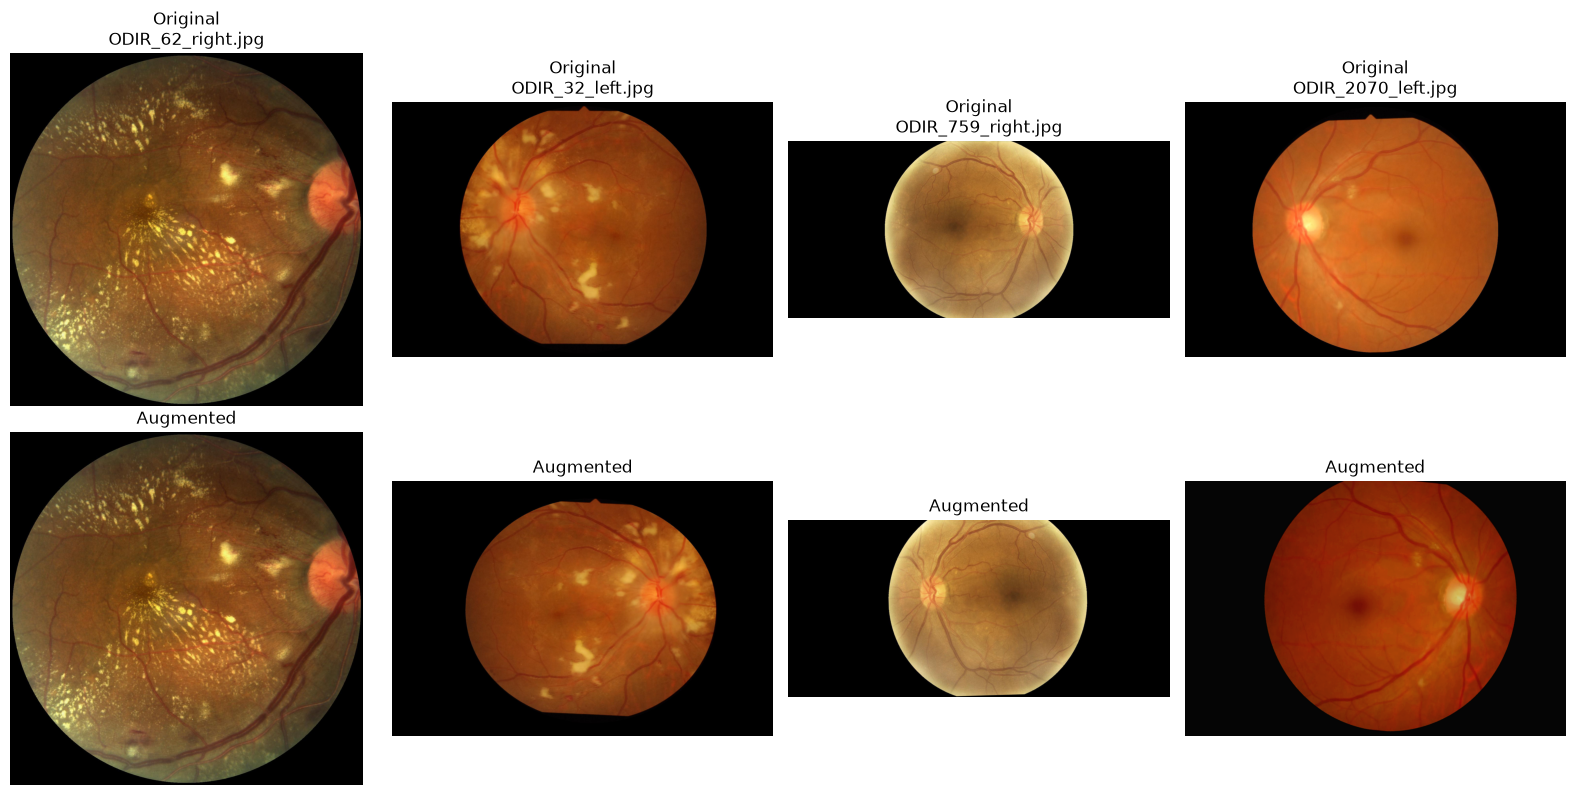

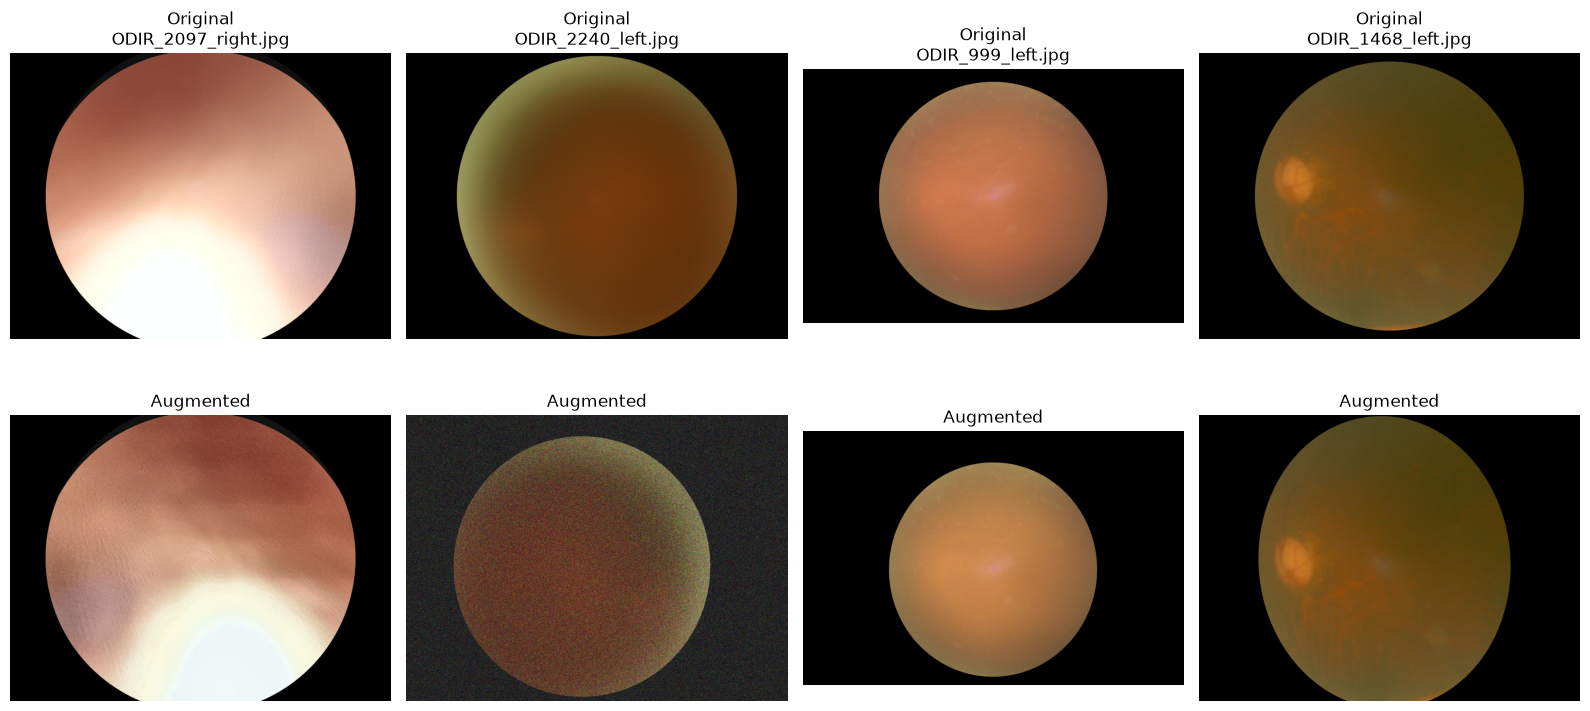

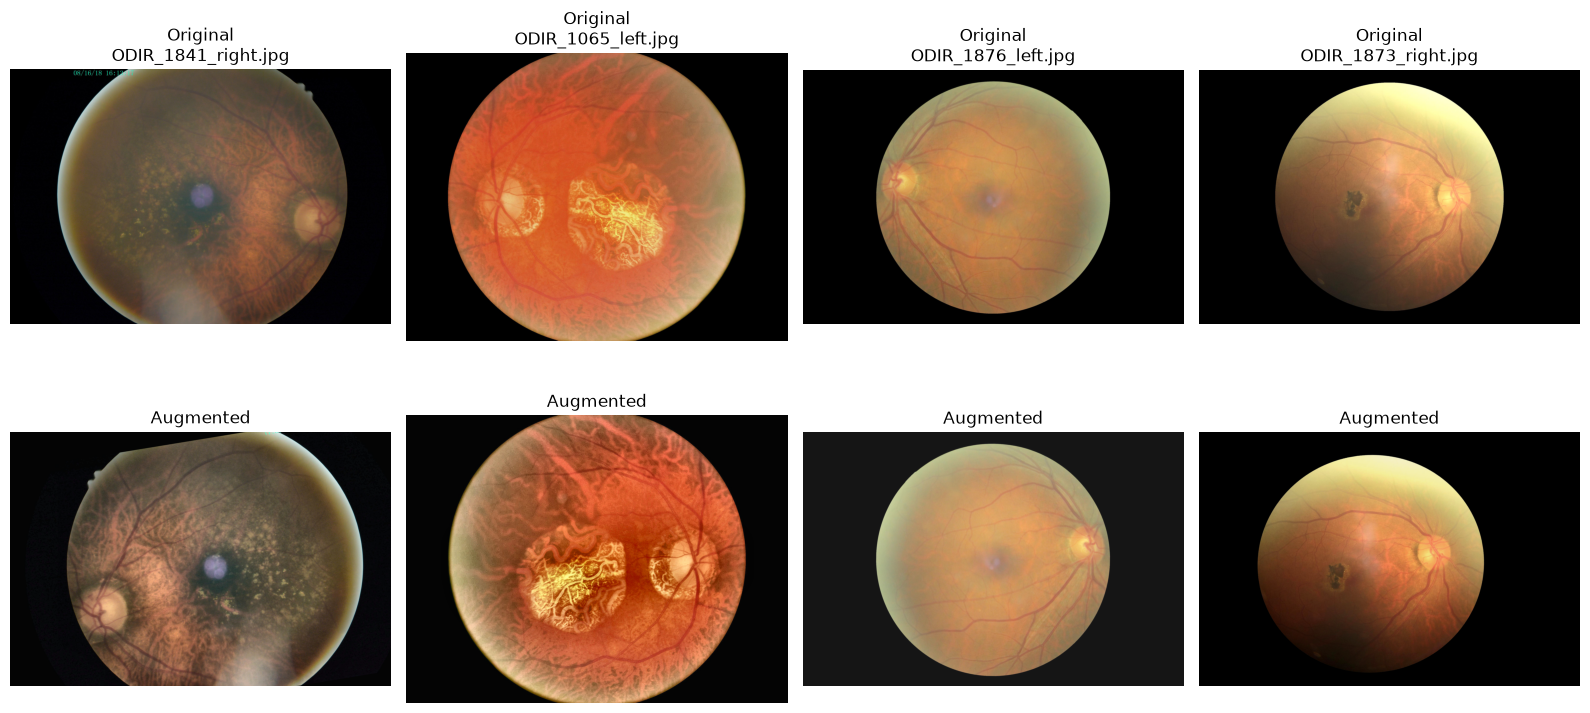

In [23]:
def preview_aug(cls, n=4):
    src = train_df[train_df['unified_label'] == cls].sample(n, random_state=0)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    for j, (_, row) in enumerate(src.iterrows()):
        p = all_files[row['filename']]
        img = np.array(Image.open(p).convert('RGB'))
        aug = aug_transform(image=img)['image']

        axes[0, j].imshow(img);   axes[0, j].set_title(f"Original\n{row['filename'][:20]}"); axes[0, j].axis('off')
        axes[1, j].imshow(aug);   axes[1, j].set_title("Augmented"); axes[1, j].axis('off')
    plt.tight_layout(); plt.show()

preview_aug('Hypertension', n=4)
preview_aug('Cataract',     n=4)
preview_aug('AMD',          n=4)

In [24]:
train_df = train_df.copy()
train_df['is_augmented']    = False
train_df['source_filename'] = train_df['filename']

train_final = pd.concat([train_df, aug_df], ignore_index=True)

# 🔑 خلي مسار كل صورة جاهز في العمود
def resolve_path(row):
    if row['is_augmented']:
        return AUG_DIR / row['unified_label'] / row['filename']
    return all_files[row['filename']]

train_final['path'] = train_final.apply(resolve_path, axis=1)

print("Train final distribution:")
print(train_final['unified_label'].value_counts())

# تأكد إن كل الصور موجودة فعلًا
missing = [p for p in train_final['path'] if not Path(p).exists()]
print(f"\nMissing files: {len(missing)}")

Train final distribution:
unified_label
Normal                  3288
Diabetic Retinopathy    2879
Others                  1500
Glaucoma                1500
Cataract                1200
AMD                     1000
Myopia                  1000
Hypertension             700
Name: count, dtype: int64

Missing files: 0


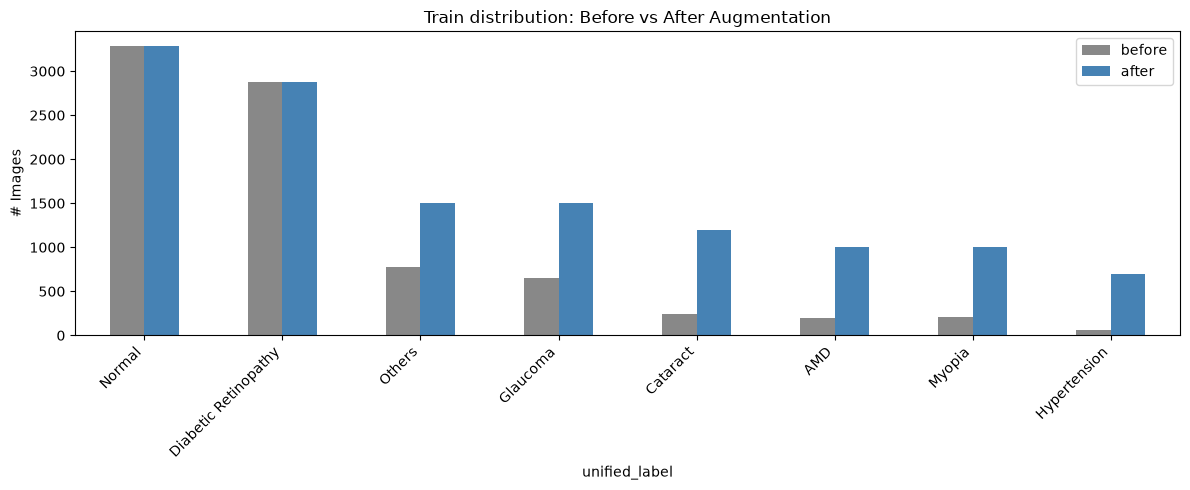


Imbalance ratio (max/min):
  Before: 53.0x
  After : 4.7x


In [25]:
before = train_dist
after  = train_final['unified_label'].value_counts()

comp = pd.DataFrame({'before': before, 'after': after}).fillna(0)
comp = comp.sort_values('after', ascending=False)

ax = comp.plot(kind='bar', figsize=(12,5), color=['#888','steelblue'])
ax.set_title('Train distribution: Before vs After Augmentation')
ax.set_ylabel('# Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print("\nImbalance ratio (max/min):")
print(f"  Before: {before.max()/before.min():.1f}x")
print(f"  After : {after.max()/after.min():.1f}x")

In [29]:
train_final.sample()

,filename,dataset,unified_label,original_label,is_augmented,source_filename,path
7378,ODIR_1160_right.jpg,ODIR5K,Others,O,False,ODIR_1160_right.jpg,D:\Education\Cellula\EyeDisease\EyeDisease\Dat...


In [26]:
# في الـ training loop
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(sorted(train_final['unified_label'].unique()))
w = compute_class_weight('balanced', classes=classes, y=train_final['unified_label'])
class_weights = dict(zip(classes, w))

In [28]:
class_weights

{np.str_('AMD'): np.float64(1.633375),
 np.str_('Cataract'): np.float64(1.3611458333333333),
 np.str_('Diabetic Retinopathy'): np.float64(0.567341090656478),
 np.str_('Glaucoma'): np.float64(1.0889166666666668),
 np.str_('Hypertension'): np.float64(2.333392857142857),
 np.str_('Myopia'): np.float64(1.633375),
 np.str_('Normal'): np.float64(0.4967685523114355),
 np.str_('Others'): np.float64(1.0889166666666668)}

In [31]:
import shutil
from pathlib import Path

# المصادر
IMAGES_DIR = Path(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\images")
AUG_DIR    = Path(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\images_augmented")
OUT_DIR    = Path(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\dataset_splits")

# file map للأصلي
all_files = {p.name: p for p in IMAGES_DIR.rglob("*") if p.is_file()}


def copy_split(df, split_name):
    """ينسخ صور الـ df إلى dataset_splits/{split_name}/{class}/"""
    for _, row in df.iterrows():
        cls_dir = OUT_DIR / split_name / row['unified_label']
        cls_dir.mkdir(parents=True, exist_ok=True)

        if row.get('is_augmented', False):
            src = AUG_DIR / row['unified_label'] / row['filename']
        else:
            src = all_files[row['filename']]

        dst = cls_dir / row['filename']
        if src.exists():
            shutil.copy2(src, dst)


# نسخ الـ 3 splits
copy_split(train_final, 'train')
copy_split(val_df,      'val')
copy_split(test_df,     'test')

print("✅ Done!")

✅ Done!


In [32]:
# نضيف عمود جديد بأسماء آمنة
def safe_name(s):
    return s.replace(" ", "_")

train_final['unified_label'] = train_final['unified_label'].apply(safe_name)
val_df['unified_label']      = val_df['unified_label'].apply(safe_name)
test_df['unified_label']     = test_df['unified_label'].apply(safe_name)

In [33]:
for split in ['train', 'val', 'test']:
    split_dir = OUT_DIR / split
    print(f"\n📁 {split}/")
    for cls_dir in sorted(split_dir.iterdir()):
        n = len(list(cls_dir.iterdir()))
        print(f"   {cls_dir.name:25s}  {n:5d} images")


📁 train/
   AMD                         1000 images
   Cataract                    1200 images
   Diabetic Retinopathy        2879 images
   Glaucoma                    1500 images
   Hypertension                 700 images
   Myopia                      1000 images
   Normal                      3288 images
   Others                      1500 images

📁 val/
   AMD                           41 images
   Cataract                      51 images
   Diabetic Retinopathy         617 images
   Glaucoma                     139 images
   Hypertension                  13 images
   Myopia                        44 images
   Normal                       705 images
   Others                       166 images

📁 test/
   AMD                           41 images
   Cataract                      51 images
   Diabetic Retinopathy         617 images
   Glaucoma                     140 images
   Hypertension                  13 images
   Myopia                        44 images
   Normal                  

In [34]:
OUT_CSV_DIR = Path(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\splits_csv")
OUT_CSV_DIR.mkdir(parents=True, exist_ok=True)

# حفظ الـ 3 splits
train_final.to_csv(OUT_CSV_DIR / "train.csv", index=False)
val_df.to_csv(     OUT_CSV_DIR / "val.csv",   index=False)
test_df.to_csv(    OUT_CSV_DIR / "test.csv",  index=False)

print("✅ Saved:")
print(f"   train.csv  →  {len(train_final)} rows")
print(f"   val.csv    →  {len(val_df)} rows")
print(f"   test.csv   →  {len(test_df)} rows")
print(f"   Location   →  {OUT_CSV_DIR}")

✅ Saved:
   train.csv  →  13067 rows
   val.csv    →  1776 rows
   test.csv   →  1776 rows
   Location   →  D:\Education\Cellula\EyeDisease\EyeDisease\Data\splits_csv


In [ ]:
class_to_idx = {c: i for i, c in enumerate(sorted(train_final['unified_label'].unique()))}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print("class_to_idx:", class_to_idx)

with open(OUT_CSV_DIR / "class_mapping.json", "w") as f:
    json.dump({
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
    }, f, indent=2)

print("✅ class_mapping.json saved")

class_to_idx: {'AMD': 0, 'Cataract': 1, 'Diabetic_Retinopathy': 2, 'Glaucoma': 3, 'Hypertension': 4, 'Myopia': 5, 'Normal': 6, 'Others': 7}
✅ class_mapping.json saved
